# 01 — Exploratory Data Analysis (EDA)

**Cel:** Poznać dataset zanim cokolwiek trenujemy. Dobre EDA to podstawa — wiemy z czym pracujemy, jakie są rozkłady, czy dane są czyste, które cechy są ważne.

**Dataset:** CIC-MalMem-2022  
**Próbki:** ~58 000 | **Cechy:** 55 | **Klasy:** Benign / Spyware / Ransomware / Trojan


In [1]:
import sys
sys.path.insert(0, '..')  # żeby Python widział folder src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Styl wykresów
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Importy OK")


Importy OK


In [2]:
from src.data.loader import load_raw_data

df = load_raw_data()
df.head(3)


Wczytano 58058 wierszy z 1 pliku/plików.
Kolumny (57): ['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit'] ...


,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555555,0,202.844452,1694,38.500000,9129,212.302322,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234039,2074,44.127659,11385,242.234039,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225006,1932,48.299999,11529,288.225006,...,222,26,27,118,0,120,88,0,8,Benign


## 1. Podstawowe informacje o datasecie

In [3]:
print(f"Liczba próbek:   {len(df):,}")
print(f"Liczba kolumn:  {len(df.columns)}")
print(f"\nKolumny meta (etykiety):")
for c in ["Category", "Class"]:
    if c in df.columns:
        print(f"  '{c}': {df[c].nunique()} unikalnych wartości")

# Ile cech numerycznych?
meta_cols = {"Category", "Class"}
feature_cols = [c for c in df.columns if c not in meta_cols]
print(f"\nCechy numeryczne: {len(feature_cols)}")
print(f"\nTypy danych:\n{df.dtypes.value_counts()}")


Liczba próbek:   58,058
Liczba kolumn:  57

Kolumny meta (etykiety):
  'Category': 28346 unikalnych wartości
  'Class': 2 unikalnych wartości

Cechy numeryczne: 55

Typy danych:
int16      23
float32    15
int8       14
int32       3
str         2
Name: count, dtype: int64


In [4]:
# Sprawdzenie brakujących wartości (NaN)
nan_counts = df[feature_cols].isnull().sum()
print("=== Brakujące wartości (NaN) ===")
print(f"Kolumny z NaN: {(nan_counts > 0).sum()} / {len(feature_cols)}")
if nan_counts.any():
    print(nan_counts[nan_counts > 0])
else:
    print("Brak NaN — dane są czyste ✓")


=== Brakujące wartości (NaN) ===
Kolumny z NaN: 0 / 55
Brak NaN — dane są czyste ✓


## 2. Rozkład klas
Sprawdzamy czy dataset jest zbalansowany — to kluczowe dla treningu.

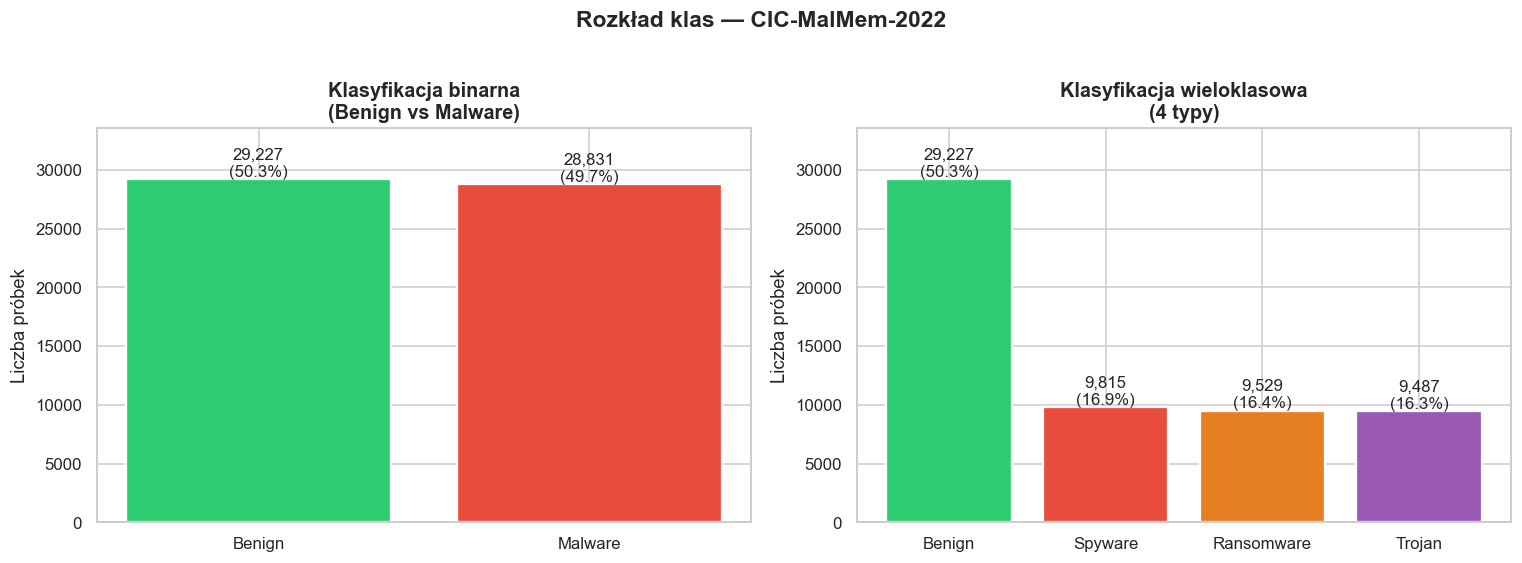

Zapis: results/plots/01_class_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Lewy wykres: Klasy binarne (Benign vs Malware) ---
binary_counts = df["Class"].value_counts()
axes[0].bar(binary_counts.index, binary_counts.values, color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
axes[0].set_title("Klasyfikacja binarna\n(Benign vs Malware)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Liczba próbek")
for i, (label, val) in enumerate(binary_counts.items()):
    axes[0].text(i, val + 200, f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=11)
axes[0].set_ylim(0, max(binary_counts.values) * 1.15)

# --- Prawy wykres: 4 klasy (multiclass) ---
# Wyciągnij typ z Category
def get_type(cat):
    return cat if cat == "Benign" else cat.split("-")[0]

type_counts = df["Category"].apply(get_type).value_counts()
colors = ["#2ecc71", "#e74c3c", "#e67e22", "#9b59b6"]
axes[1].bar(type_counts.index, type_counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Klasyfikacja wieloklasowa\n(4 typy)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Liczba próbek")
for i, (label, val) in enumerate(type_counts.items()):
    axes[1].text(i, val + 200, f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=11)
axes[1].set_ylim(0, max(type_counts.values) * 1.15)

plt.suptitle("Rozkład klas — CIC-MalMem-2022", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../results/plots/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Zapis: results/plots/01_class_distribution.png")


## 3. Statystyki cech

Sprawdzamy zakres wartości, średnią i odchylenie standardowe każdej cechy.  
Interesuje nas: czy cechy są w drastycznie różnych skalach? (dlatego robimy normalizację Min-Max)

In [6]:
stats = df[feature_cols].describe().T
stats["range"] = stats["max"] - stats["min"]
stats_show = stats[["mean", "std", "min", "max", "range"]].round(3)

# Top 10 cech o największym zakresie wartości
print("=== Top 10 cech o największym zakresie (max - min) ===")
print(stats_show.nlargest(10, "range").to_string())

print(f"\n=== Cechy z wartościami zerowymi (min=0 i max=0) ===")
zero_cols = stats[(stats["min"] == 0) & (stats["max"] == 0)].index.tolist()
print(f"  {len(zero_cols)} kolumny: {zero_cols[:5]} {'...' if len(zero_cols) > 5 else ''}")


=== Top 10 cech o największym zakresie (max - min) ===
                                   mean       std       min          max        range
handles.nhandles              10274.033  4884.754  3514.000  1047310.000  1043796.000
handles.nfile                   901.054  3448.131   266.000   807008.000   806742.000
malfind.commitCharge            977.255  6067.240     1.000   220850.000   220849.000
handles.avg_handles_per_proc    249.851   146.615    71.139    33784.195    33713.056
pslist.avg_handlers             247.800   112.289    34.963    24845.951    24810.989
handles.nsection                291.011   144.429    50.000    14687.000    14637.000
handles.nevent                 3577.823   805.505   966.000     7892.000     6926.000
handles.nthread                 930.099   237.885   388.000     5637.000     5249.000
handles.nsemaphore              683.963    94.435   296.000     4268.000     3972.000
malfind.protection               42.466    92.657     6.000     3762.000     3756.000

## 4. Boxploty — czy cechy odróżniają malware od benign?

**Boxplot** pokazuje rozkład wartości danej cechy dla każdej klasy.  
Jeśli pudełka (klasy) są daleko od siebie → cecha jest dobra do wykrywania malware.  
Jeśli nachodzą na siebie → cecha mało przydatna.

Wybieramy 12 najbardziej "różniących" cech (największa różnica średnich między benign a malware).

Top 12 cech odróżniających Benign od Malware:
   1. handles.nhandles  (diff = 3717.352)
   2. malfind.commitCharge  (diff = 1947.221)
   3. handles.nevent  (diff = 1411.918)
   4. dlllist.ndlls  (diff = 543.154)
   5. handles.nthread  (diff = 414.875)
   6. handles.nfile  (diff = 299.617)
   7. handles.nsection  (diff = 236.822)
   8. handles.nkey  (diff = 209.885)
   9. handles.nsemaphore  (diff = 145.217)
  10. handles.nmutant  (diff = 125.101)
  11. pslist.avg_handlers  (diff = 74.671)
  12. handles.avg_handles_per_proc  (diff = 74.368)


C:\Users\Laptop\AppData\Local\Temp\ipykernel_15204\3723746463.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="Class", y=col, ax=ax,
C:\Users\Laptop\AppData\Local\Temp\ipykernel_15204\3723746463.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="Class", y=col, ax=ax,
C:\Users\Laptop\AppData\Local\Temp\ipykernel_15204\3723746463.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="Class", y=col, ax=ax,
C:\Users\Laptop\AppData\Local\Temp\ipykernel_15204\3723746463.py:24: FutureWarning: 

Pa

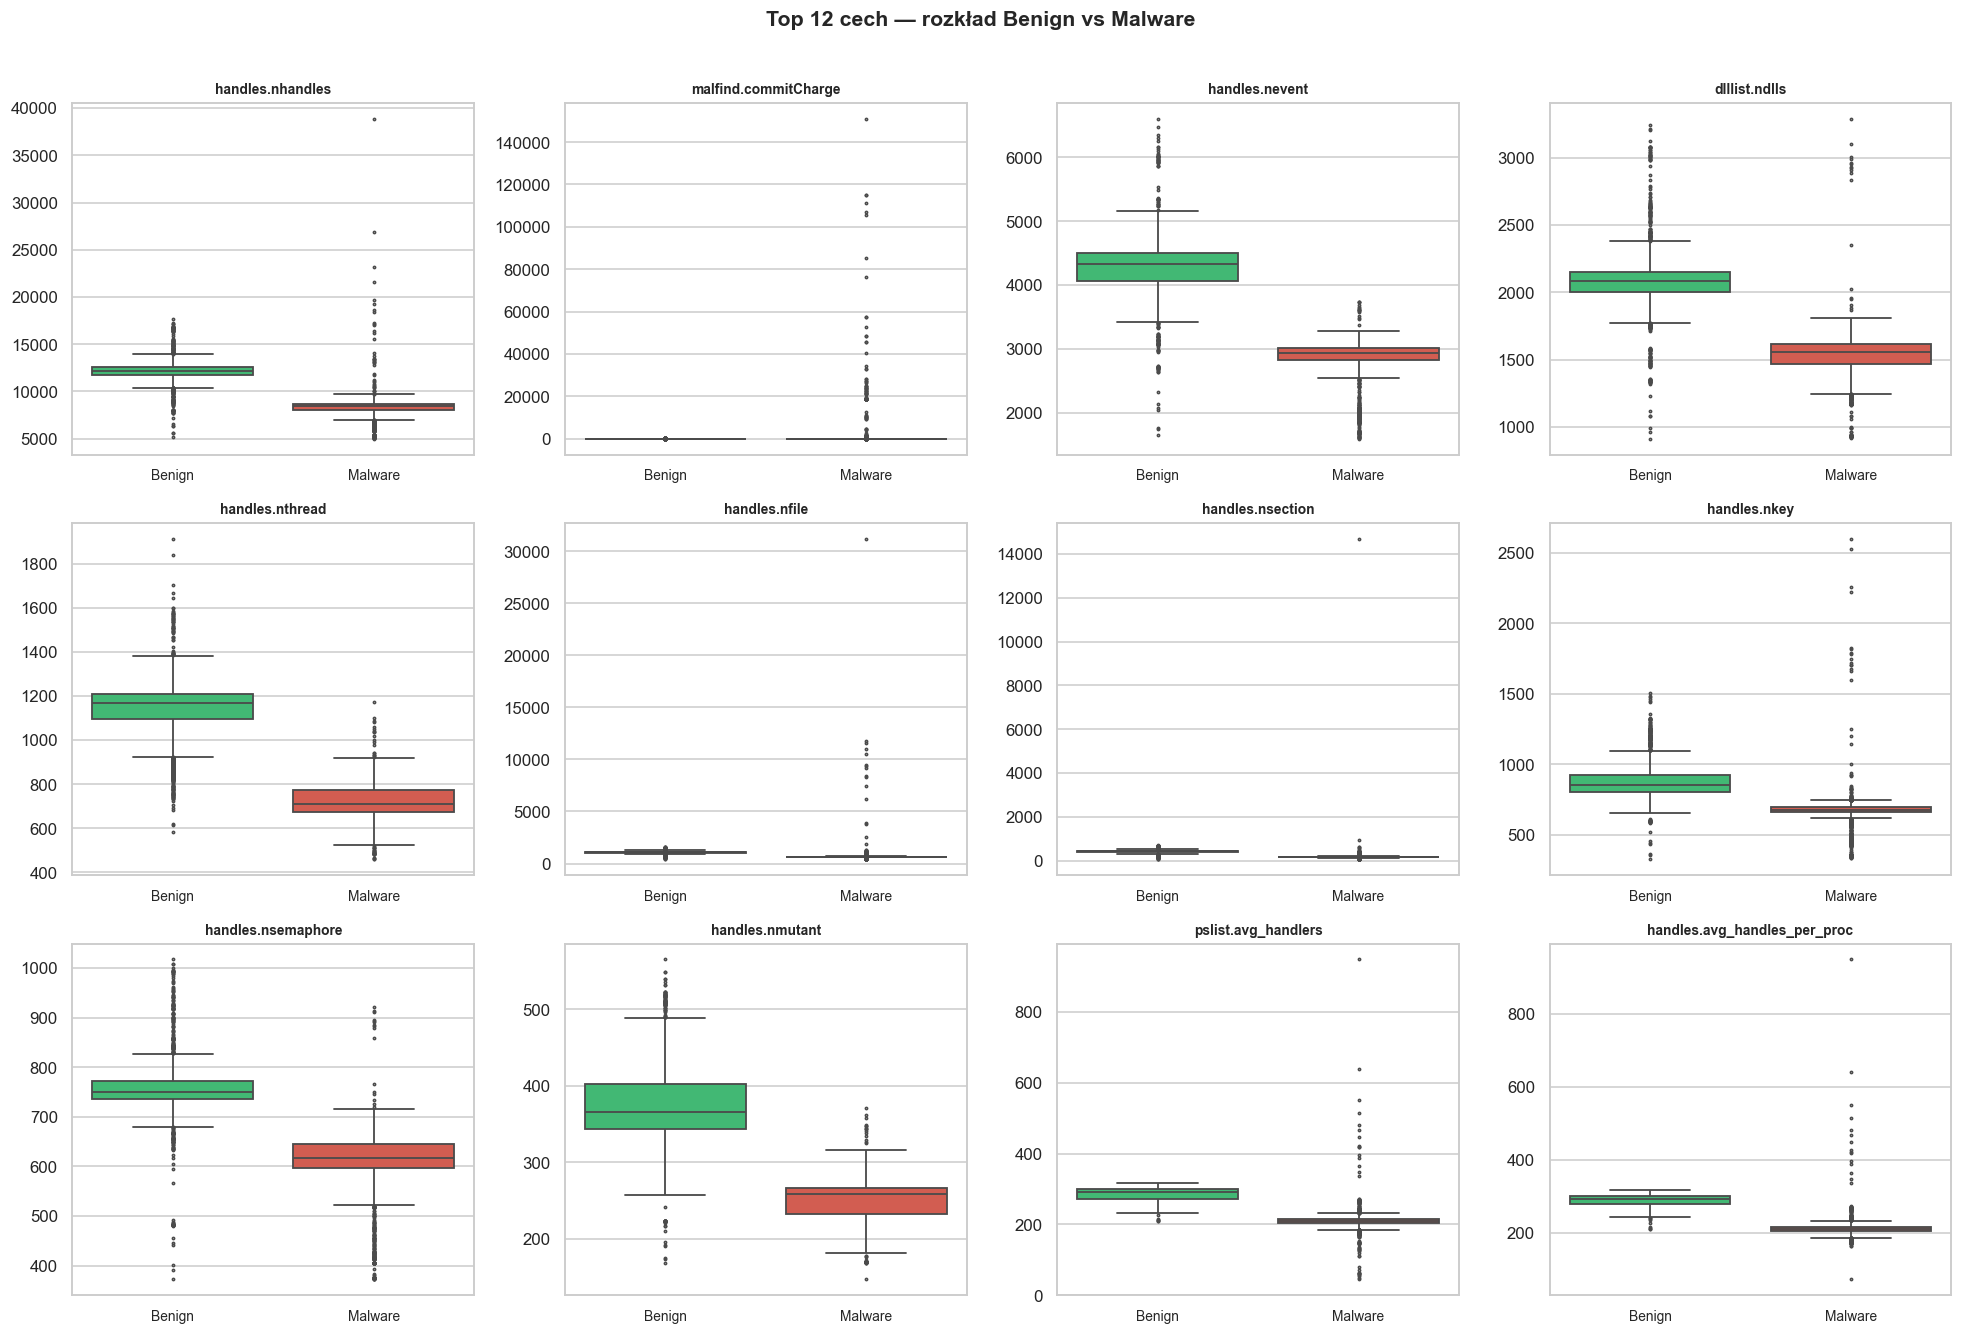

In [8]:
df_plot = df[feature_cols + ["Class"]].copy()

# Wybierz 12 cech z największą różnicą średnich (benign vs malware)
means_benign  = df_plot[df_plot["Class"] == "Benign"][feature_cols].mean()
means_malware = df_plot[df_plot["Class"] == "Malware"][feature_cols].mean()
diff = (means_malware - means_benign).abs().sort_values(ascending=False)
top12 = diff.head(12).index.tolist()

print("Top 12 cech odróżniających Benign od Malware:")
for i, col in enumerate(top12, 1):
    print(f"  {i:2d}. {col}  (diff = {diff[col]:.3f})")

# Wykres
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(top12):
    ax = axes[i]
    # Próbkujemy żeby wykres był szybszy (max 3000 próbek na klasę)
    sample = pd.concat([
        df_plot[df_plot["Class"] == c].sample(min(len(df_plot[df_plot["Class"] == c]), 3000), random_state=42)
        for c in ["Benign", "Malware"]
    ]).reset_index(drop=True)
    sns.boxplot(data=sample, x="Class", y=col, ax=ax,
                palette={"Benign": "#2ecc71", "Malware": "#e74c3c"},
                fliersize=1.5, linewidth=1.2)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle("Top 12 cech — rozkład Benign vs Malware", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

plt.savefig("../results/plots/02_feature_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Porównanie typów malware (4 klasy)

Sprawdzamy czy różne typy malware (Spyware / Ransomware / Trojan) mają różne "sygnatury" w pamięci.  
Jeśli tak → klasyfikacja wieloklasowa ma sens. Jeśli wszystkie wyglądają tak samo → trudniejsze zadanie.

C:\Users\Laptop\AppData\Local\Temp\ipykernel_15204\1839589101.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="_type", y=col, ax=ax, palette=palette,
C:\Users\Laptop\AppData\Local\Temp\ipykernel_15204\1839589101.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="_type", y=col, ax=ax, palette=palette,
C:\Users\Laptop\AppData\Local\Temp\ipykernel_15204\1839589101.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x="_type", y=col, ax=ax, palette=palette,
C:\Users\Laptop\AppData\Local\Temp\ip

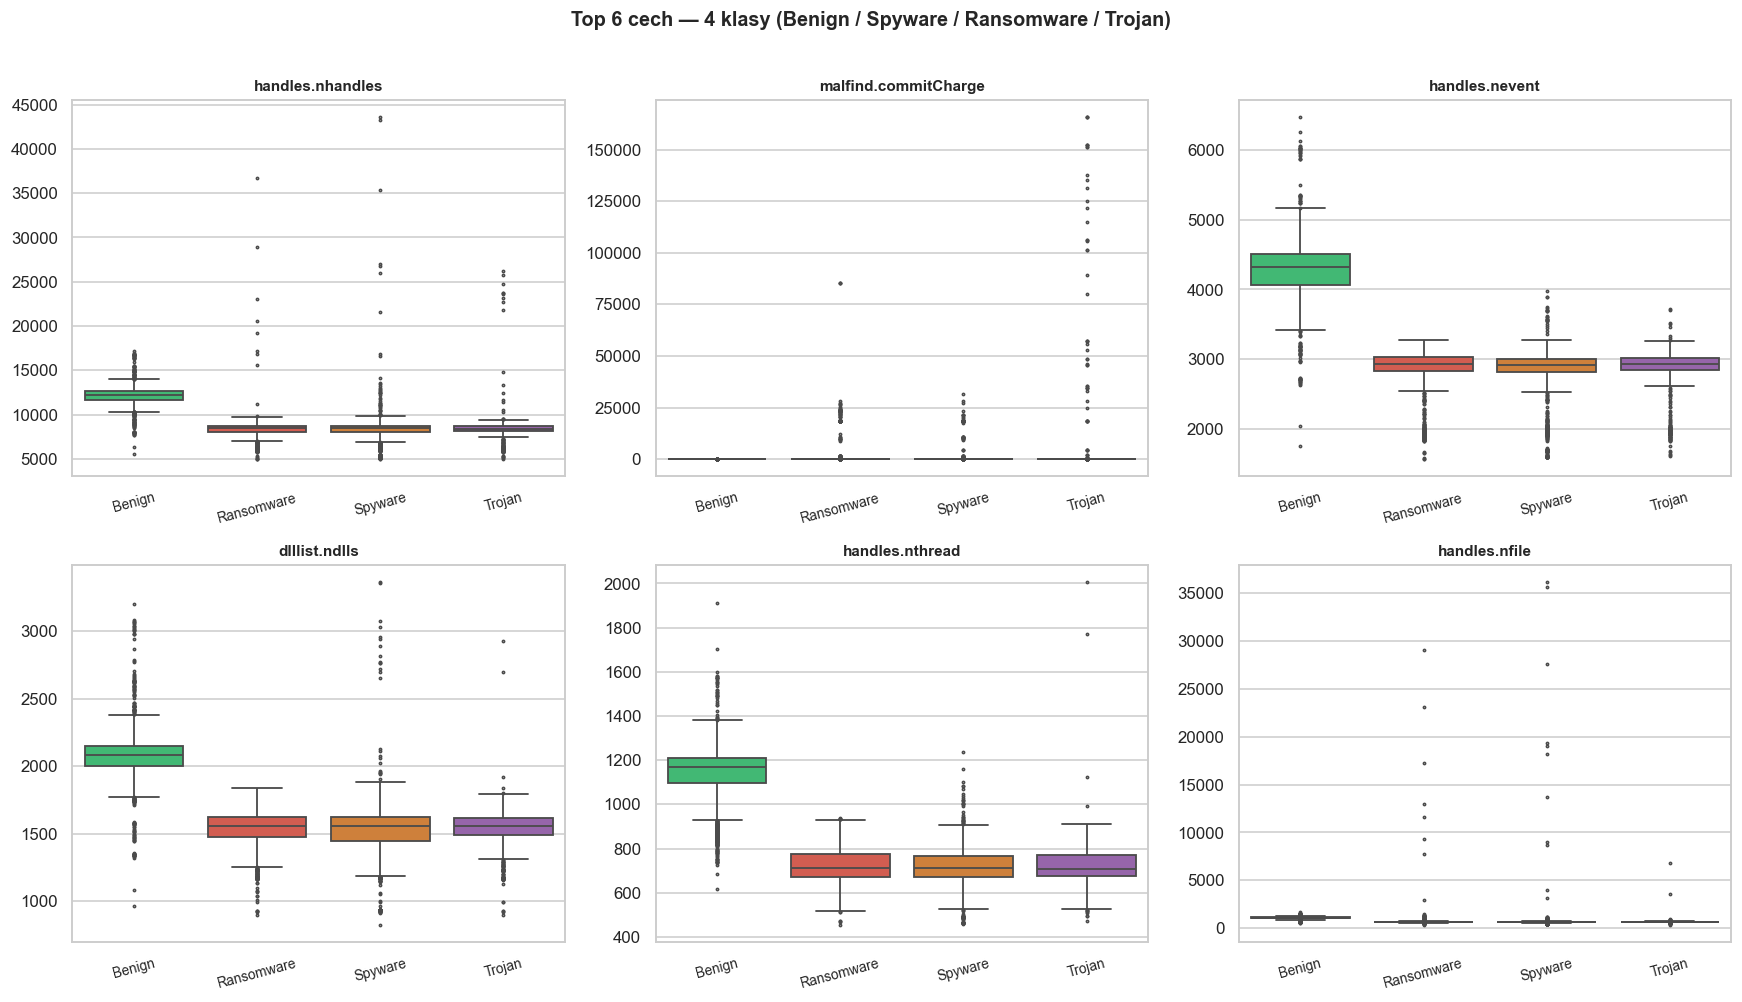

In [9]:
df["_type"] = df["Category"].apply(lambda c: c if c == "Benign" else c.split("-")[0])

# Wybierz top 6 cech i pokaż je dla 4 klas
top6 = diff.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

palette = {"Benign": "#2ecc71", "Ransomware": "#e74c3c", "Spyware": "#e67e22", "Trojan": "#9b59b6"}

for i, col in enumerate(top6):
    ax = axes[i]
    sample = pd.concat([
        df[df["_type"] == c].sample(min(len(df[df["_type"] == c]), 2000), random_state=42)
        for c in ["Benign", "Ransomware", "Spyware", "Trojan"]
    ]).reset_index(drop=True)
    sns.boxplot(data=sample, x="_type", y=col, ax=ax, palette=palette,
                fliersize=1.5, linewidth=1.2)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', labelsize=9, rotation=15)

plt.suptitle("Top 6 cech — 4 klasy (Benign / Spyware / Ransomware / Trojan)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

plt.savefig("../results/plots/03_multiclass_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Macierz korelacji cech

Korelacja mierzy czy dwie cechy poruszają się razem (wartości bliskie 1 lub -1).  
Silnie skorelowane cechy dają podobne informacje → autoencoder może je "połączyć" w latent space.  
Pokazujemy tylko top 20 cech dla czytelności.

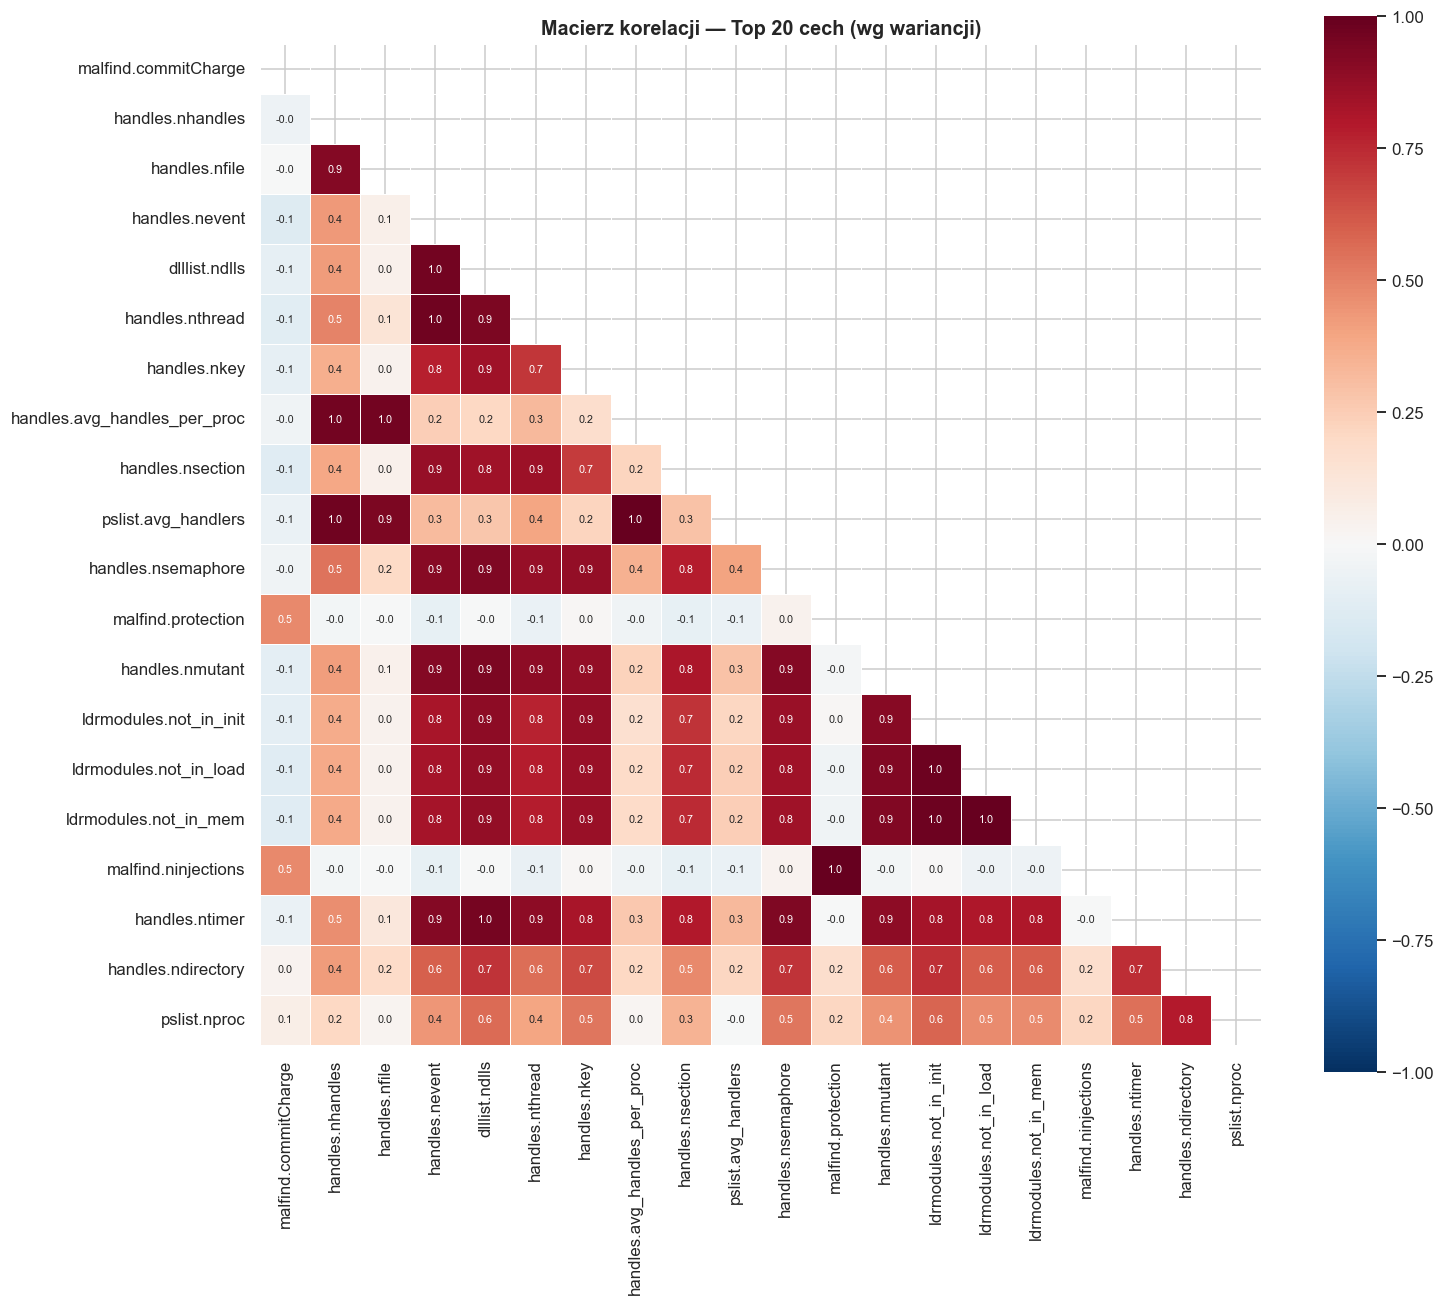

In [10]:
# Bierzemy top 20 cech z największą wariancją (bardziej zróżnicowane = bardziej interesujące)
top20 = df[feature_cols].var().nlargest(20).index.tolist()
corr = df[top20].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # ukryj górny trójkąt (duplikaty)
sns.heatmap(
    corr, mask=mask, ax=ax, cmap="RdBu_r", center=0,
    annot=True, fmt=".1f", annot_kws={"size": 7},
    linewidths=0.5, square=True, vmin=-1, vmax=1
)
ax.set_title("Macierz korelacji — Top 20 cech (wg wariancji)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/plots/04_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Podsumowanie EDA

Po uruchomieniu wszystkich komórek uzupełnij wnioski poniżej.

In [11]:
from src.data.loader import preprocess

print("=" * 55)
print("  PODSUMOWANIE DATASETU")
print("=" * 55)
print(f"  Łączna liczba próbek:  {len(df):,}")
print(f"  Liczba cech:           {len(feature_cols)}")
print(f"  NaN:                   {df[feature_cols].isnull().sum().sum()}")
print()
print("  Rozkład klas (binary):")
for cls, cnt in df["Class"].value_counts().items():
    print(f"    {cls:<10} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")
print()
print("  Rozkład klas (multiclass):")
for cls, cnt in df["_type"].value_counts().items():
    print(f"    {cls:<12} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

print()
print("  Wykresy zapisane w: results/plots/")
print()
print("  NASTĘPNY KROK → notebooks/02_baseline.ipynb")
print("    Prosta sieć FC trenowana na labeled data (punkt odniesienia)")


  PODSUMOWANIE DATASETU
  Łączna liczba próbek:  58,058
  Liczba cech:           55
  NaN:                   0

  Rozkład klas (binary):
    Benign     29,227  (50.3%)
    Malware    28,831  (49.7%)

  Rozkład klas (multiclass):
    Benign       29,227  (50.3%)
    Spyware       9,815  (16.9%)
    Ransomware    9,529  (16.4%)
    Trojan        9,487  (16.3%)

  Wykresy zapisane w: results/plots/

  NASTĘPNY KROK → notebooks/02_baseline.ipynb
    Prosta sieć FC trenowana na labeled data (punkt odniesienia)
